# ARIMA Residual Analysis

## Purpose
Evaluates the residuals of the **ARIMA(1,0,0)** model — the best converged configuration identified by the grid search — to assess whether any systematic error structure remains. Residuals should be approximately **white noise**: zero mean, constant variance, and no significant autocorrelation.

A non-zero mean in the residuals indicates a bias that can be estimated and corrected in the next stage.

## Inputs
- `data/dataset.csv` — Training dataset (93 monthly observations)

## Outputs
- Residual summary statistics and distribution plots.

In [1]:
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA
from matplotlib import pyplot as plt
from sklearn.metrics import mean_squared_error
from math import sqrt


## Differencing and Inverse-Difference Helpers

Identical utilities used throughout this project.

In [2]:
# create a differenced series
def difference(dataset, interval=1):
    diff = list()
    for i in range(interval, len(dataset)):
        value = dataset[i] - dataset[i - interval]
        diff.append(value)
    return diff

In [3]:
# invert differenced value
def inverse_difference(history, yhat, interval=1):
    return yhat + history[-interval]

## Load Training Data

In [4]:
series = pd.read_csv('data/dataset.csv', index_col=0, parse_dates=True).iloc[:, 0]
series.head()

Month
1964-01-01    2815
1964-02-01    2672
1964-03-01    2755
1964-04-01    2721
1964-05-01    2946
Name: Sales, dtype: int64

## Train / Test Split

50/50 split, consistent with all preceding notebooks.

In [5]:
# prepare data
X = series.values
X = X.astype('float64')
train_size = int(len(X) * 0.50)
train, test = X[0:train_size], X[train_size:]

## Walk-Forward Validation — ARIMA(1,0,0)

Generate one-step-ahead forecasts using the grid-search winner: **ARIMA(1,0,0)** on the seasonally differenced series. Predictions are inverted back to the original scale after each step. True observations are appended to history at each step to keep the model updated.

In [6]:
# walk-forward validation
history = [x for x in train]
predictions = list()
for i in range(len(test)):
    # difference data
    months_in_year = 12
    diff = difference(history, months_in_year)
    # predict
    model = ARIMA(diff, order=(1, 0, 0))
    model_fit = model.fit()
    yhat = model_fit.forecast()[0]
    yhat = inverse_difference(history, yhat, months_in_year)
    predictions.append(yhat)
    # observation
    obs = test[i]
    history.append(obs)

## Residual Summary Statistics

Compute the residuals (`actual − predicted`) and call `describe()`. Pay particular attention to the **mean**: a value significantly different from zero signals a systematic bias in the model's predictions that should be explicitly corrected before deployment.

In [7]:
# errors
residuals = [test[i]-predictions[i] for i in range(len(test))]
residuals = pd.DataFrame(residuals)
print(residuals.describe())

                 0
count    47.000000
mean   -196.036836
std     934.547654
min   -2321.638606
25%    -685.704035
50%    -240.907923
75%     362.380192
max    2190.719757


## Residual Distribution

A histogram and KDE of the residuals. Ideally these should be approximately symmetric and bell-shaped, centred near zero. Skewness or heavy tails suggest the model is leaving structure unexplained.

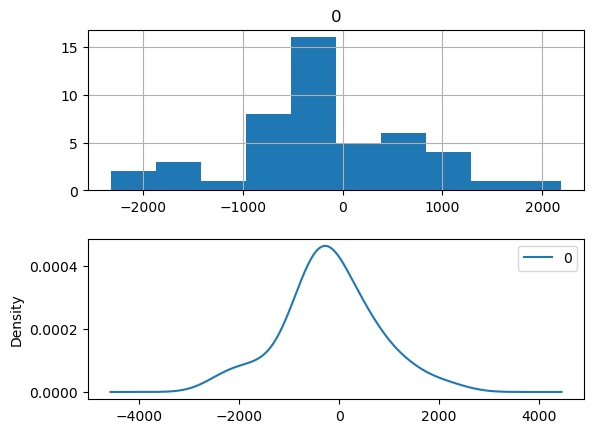

In [8]:
plt.figure();
plt.subplot(211);
residuals.hist(ax=plt.gca());
plt.subplot(212);
residuals.plot(kind='kde', ax=plt.gca());